In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pyana 
import h5py

# claude --resume 61dfd1a0-8b5d-4491-a503-0889123c862e

In [68]:
#atmos = np.load('/dat/milic/3D/3D_full_subdomain/cutout_0.npy', allow_pickle=True)

#atmos = pyana.fzread('/home/milic/codes/snapy/10_sloja_no_phys.f0')["data"]
atmos = h5py.File('/scratch/vigeesh/for_ivan/job3D960x960x280_v50_rhd_t006030s.h5', 'r')

In [69]:
atmos.keys()

<KeysViewHDF5 ['T', 'bx', 'by', 'bz', 'p', 'rho', 'tau', 'vx', 'vy', 'vz', 'x', 'y', 'z']>

In [70]:
z = atmos['z'][:]

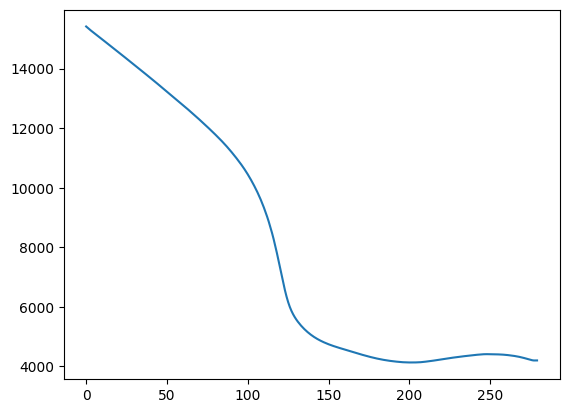

In [71]:
T_mean = np.mean(atmos['T'][:,:,:], axis=(1,2))
plt.plot(T_mean)

In [72]:
vx = atmos['vx'][:,:,:]
vy = atmos['vy'][:,:,:]
vz = atmos['vz'][:,:,:]
T = atmos['T'][:,:,:]

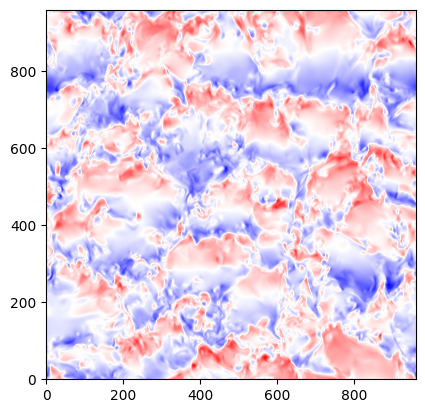

In [73]:
plt.imshow(vx[115,:,:].T/1E5, origin='lower', cmap='bwr')

In [74]:
# Now we need to analyze tau: 
tau = atmos['tau'][:,:,:]
print(tau.shape)

(280, 960, 960)


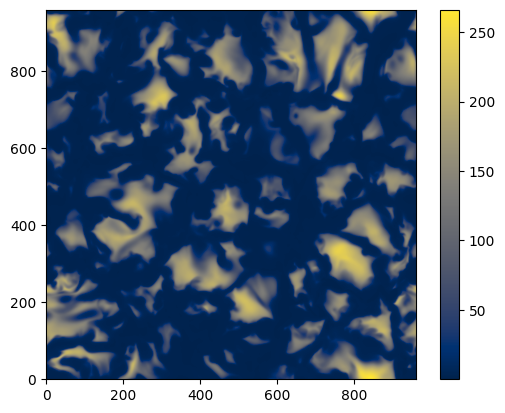

In [75]:
plt.imshow(tau[115,:,:].T, origin='lower', cmap='cividis')
plt.colorbar()
#plt.show()

In [76]:
# Here we want to re-interpolate from z to tau, to have an equidistant grid in tau and then extract tau = 1.0, 1E-1 ... 1E-4

tau_values = [1.0, 1E-1, 1E-2, 1E-3, 1E-4]
tau_values = tau_values[::-1]
v_x_tau = np.zeros((len(tau_values), tau.shape[1], tau.shape[2]))
v_y_tau = np.zeros((len(tau_values), tau.shape[1], tau.shape[2]))
v_z_tau = np.zeros((len(tau_values), tau.shape[1], tau.shape[2]))
T_tau = np.zeros((len(tau_values), tau.shape[1], tau.shape[2]))

from tqdm import tqdm

# Find them through depth interpolation:
for i in tqdm(range(tau.shape[1])):
    for j in range(tau.shape[2]):
        v_x_tau[:,i,j] = np.interp(tau_values, tau[::-1,i,j], vx[::-1,i,j])
        v_y_tau[:,i,j] = np.interp(tau_values, tau[::-1,i,j], vy[::-1,i,j])
        v_z_tau[:,i,j] = np.interp(tau_values, tau[::-1,i,j], vz[::-1,i,j])
        T_tau[:,i,j] = np.interp(tau_values, tau[::-1,i,j], T[::-1,i,j])

100%|██████████| 960/960 [00:49<00:00, 19.21it/s]


In [77]:
# Now save this as a npz file for Stefani, swapping the meaning of v_x and vy, to take into account different convention of CO5BOLD
np.savez('/dat/milic/3D/3D_snapi_cubes/job3D960x960x280_v50_rhd_t006030s_v_tau.npz', v_x_tau=v_y_tau, v_y_tau=v_x_tau, v_z_tau=v_z_tau)

In [58]:
vtaus = np.load('/dat/milic/3D/3D_snapi_cubes/job3D960x960x280_v50_rhd_t006000s_v_tau.npz')
v_x_tau = vtaus['v_x_tau']
v_y_tau = vtaus['v_y_tau']
v_z_tau = vtaus['v_z_tau']

In [59]:
v_x_tau.shape

(5, 960, 960)

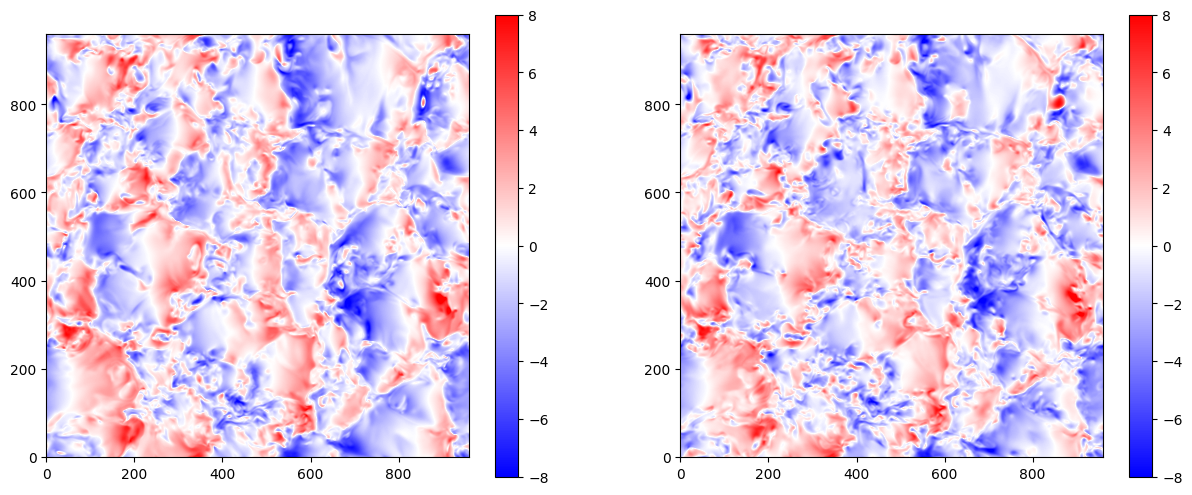

In [66]:
plt.figure(figsize=[15,6])
plt.subplot(121)
plt.imshow(v_x_tau[-1,:,:].T/1E5, origin='lower', cmap='bwr', vmin=-8,vmax=8)
plt.colorbar()
plt.subplot(122)
plt.imshow(vy[115,:,:].T/1E5, origin='lower', cmap='bwr', vmin=-8,vmax=8)
plt.colorbar()

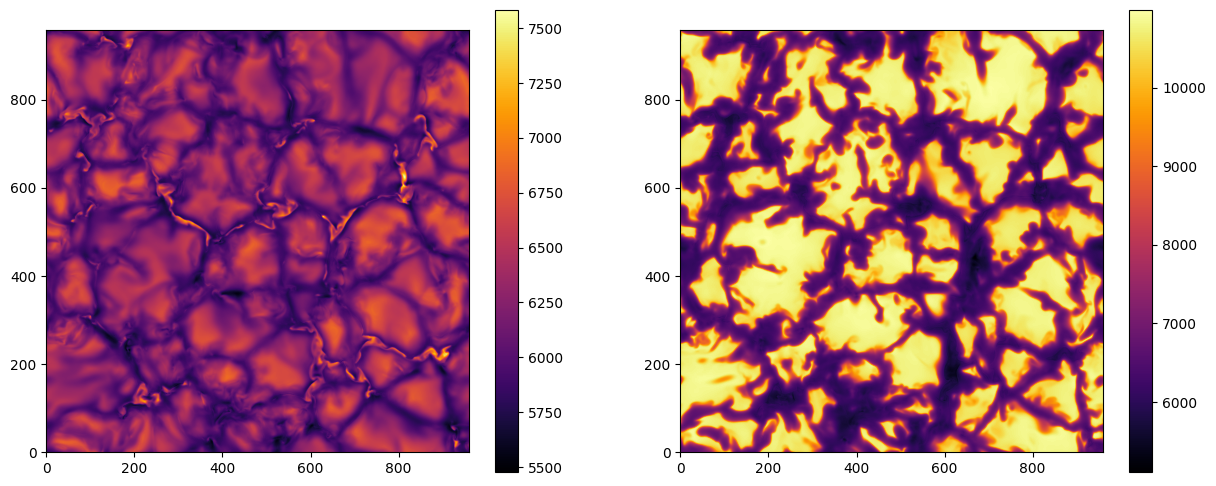

In [67]:
# Same but for the temperature: 
plt.figure(figsize=[15,6])
plt.subplot(121)
plt.imshow(T_tau[-1,:,:].T, origin='lower', cmap='inferno')
plt.colorbar()
plt.subplot(122)
plt.imshow(T[115,:,:].T, origin='lower', cmap='inferno')
plt.colorbar()